In [3]:
import os
import librosa
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

## Importing Audio

In [1]:
random_file_name = "Data/genres_original/blues/blues.00000.wav"

## Visualising Audio

In [ ]:
y, sr = librosa.load(random_file_name, sr = 44100)
plt.figure(figsize=(14, 5))
librosa.display.waveshow(y, sr = sr)

## Play sound

In [ ]:
from IPython.display import Audio
Audio(data=y, rate=sr)

## Doing visualization on chunks of audio

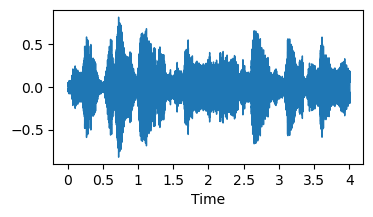

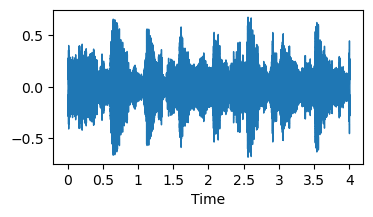

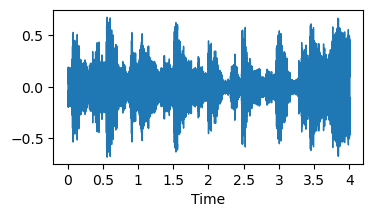

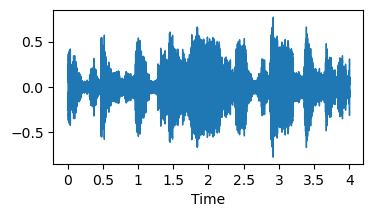

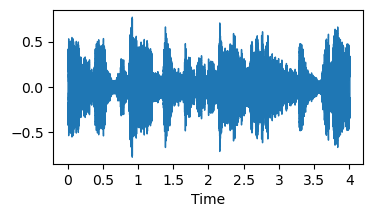

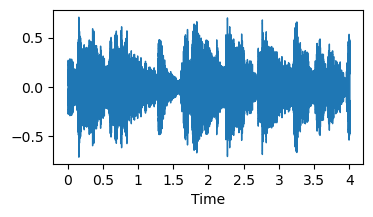

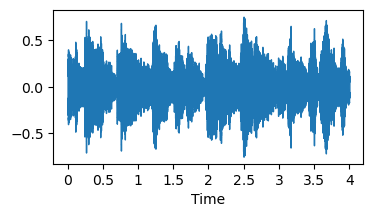

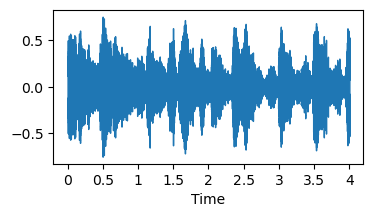

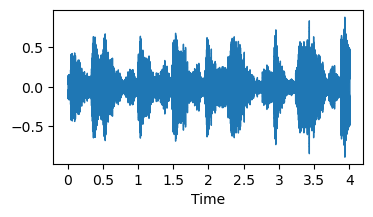

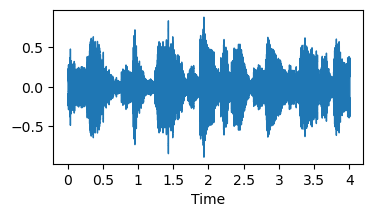

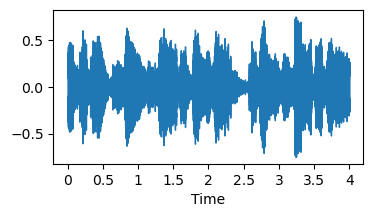

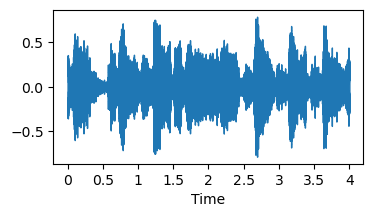

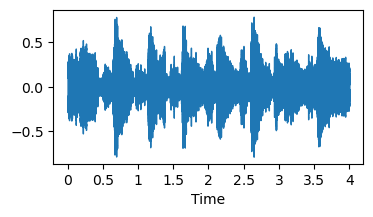

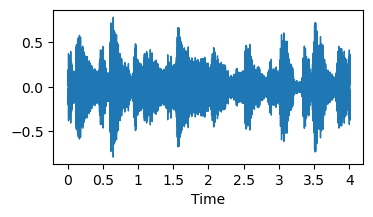

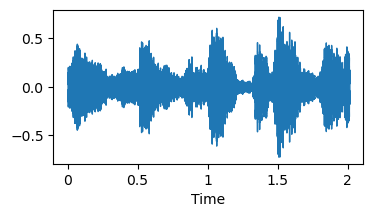

In [ ]:
audio_path = "Data/genres_original/blues/blues.00000.wav"
y, sr = librosa.load(random_file_name, sr=None) #sr = None to keep orgiinal sampking rate


#define the duration of each chunk and overlap
chunk_duration = 4 # 4sec
overlap_duration = 2 # overlap because to mainatin prevoius inforamtion

# COnvert duration to sample
chunk_samples = chunk_duration * sr
overlap_samples = overlap_duration * sr

# Calucalte no. of chunks
num_chunks = int(np.ceil(
    (len(y) - chunk_samples) / (chunk_samples-overlap_samples)
)) + 1

# Iterate over each chunks
for i in range(num_chunks):
    #calculate start & end indices of chunk
    start = i* (chunk_samples-overlap_samples)
    end = start + chunk_samples

    #extract chunk audio
    chunk = y[start:end]
    plt.figure(figsize=(4,2))
    librosa.display.waveshow(chunk, sr = sr)
    plt.show()

In [ ]:
y.shape

(661794,)

In [ ]:
# MELSPECTEROGRAM

In [ ]:
#plotting Melspectrogram of entire Audio
def plot_melspectrogram(y, sr):
    #Compute spectrogram
    spectrogram = librosa.feature.melspectrogram(y=y, sr = sr)
    #Convert to decibels(log, scale)
    spectrogram_db = librosa.power_to_db( spectrogram, ref=np.max)
    #visualize the spectrgoram
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(spectrogram_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format = '%2.0f dB')
    plt.title("Spectrogram")
    plt.tight_layout()
    plt.show()

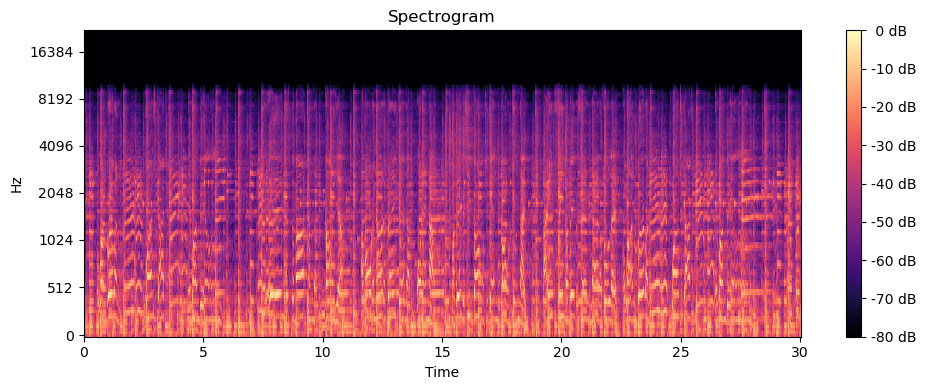

In [ ]:
y, sr = librosa.load(random_file_name, sr = 44100)
plot_melspectrogram(y, sr)

In [ ]:
def plot_melspectrogram_chunks(y, sr):
    #define the duration of each chunk and overlap
    chunk_duration = 4
    overlap_duration = 2

    chunk_samples = chunk_duration * sr
    overlap_samples = overlap_duration * sr

    num_chunks = int(np.ceil(
        (len(y) - chunk_samples) / (chunk_samples-overlap_samples)
    )) + 1

    # Iterate over each chunks
    for i in range(num_chunks):
        #calculate start & end indices of chunk
        start = i* (chunk_samples-overlap_samples)
        end = start + chunk_samples

        #extract chunk audio
        chunk = y[start:end]

        #Melsprectrogram
        spectrogram = librosa.feature.melspectrogram(y = chunk, sr = sr)
        print(spectrogram.shape)
        spectrogram_db = librosa.power_to_db( spectrogram, ref=np.max)

        # visualize the spectrogram
        plt.figure(figsize=(10, 4))
        librosa.display.specshow(spectrogram_db, sr=sr, x_axis='time', y_axis='mel')
        plt.colorbar(format = '%2.0f dB')
        plt.title("Spectrogram")
        plt.tight_layout()
        plt.show()


(128, 345)


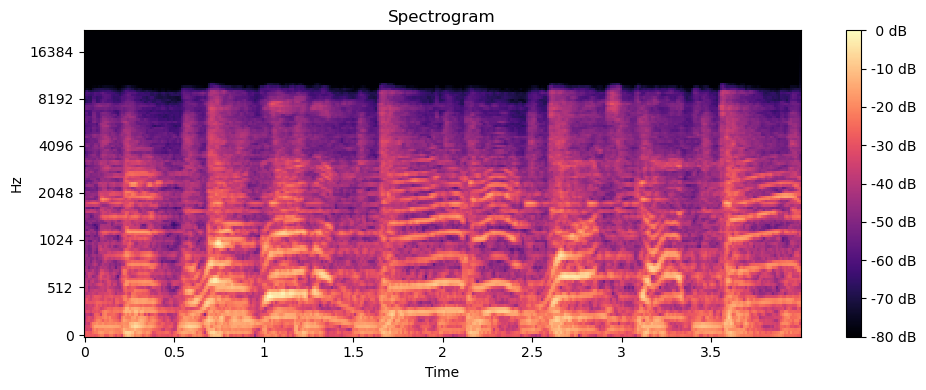

(128, 345)


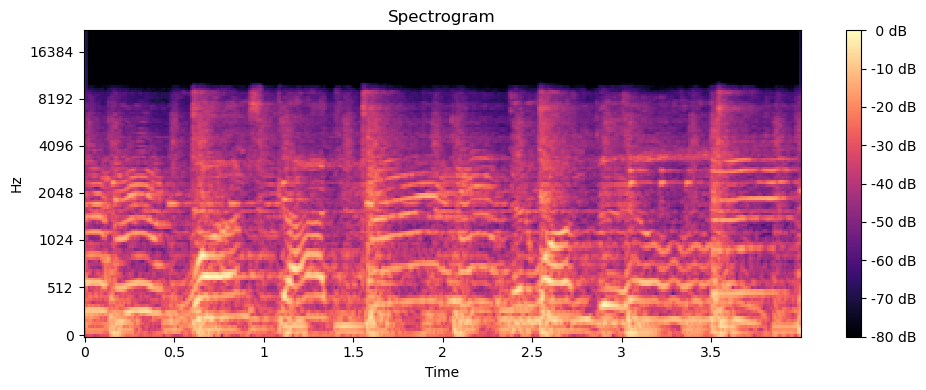

(128, 345)


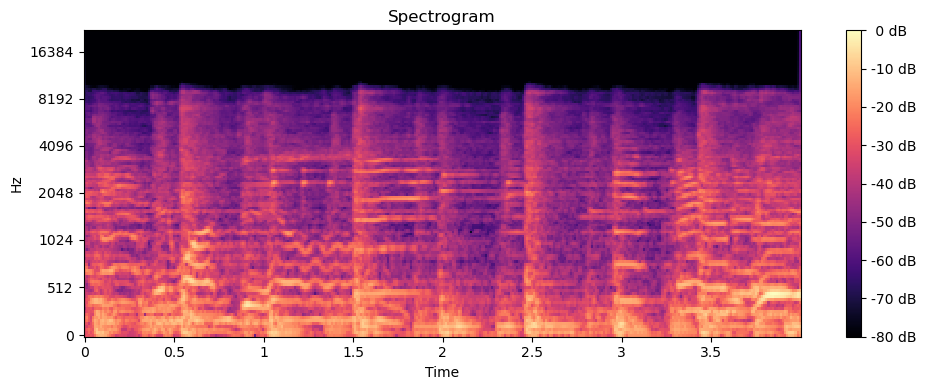

(128, 345)


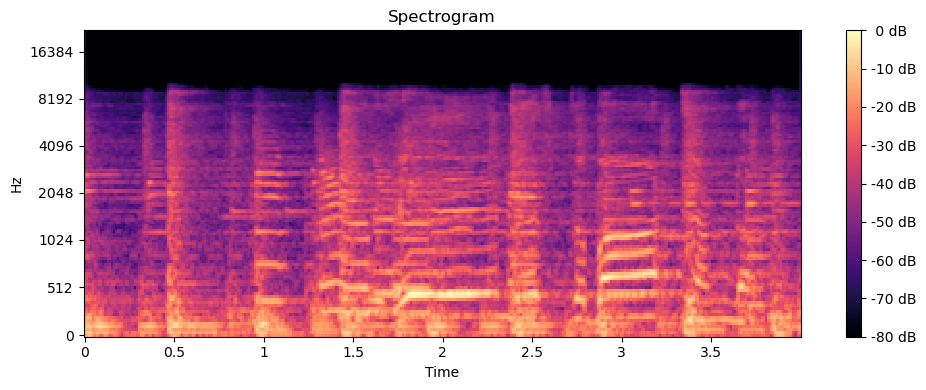

(128, 345)


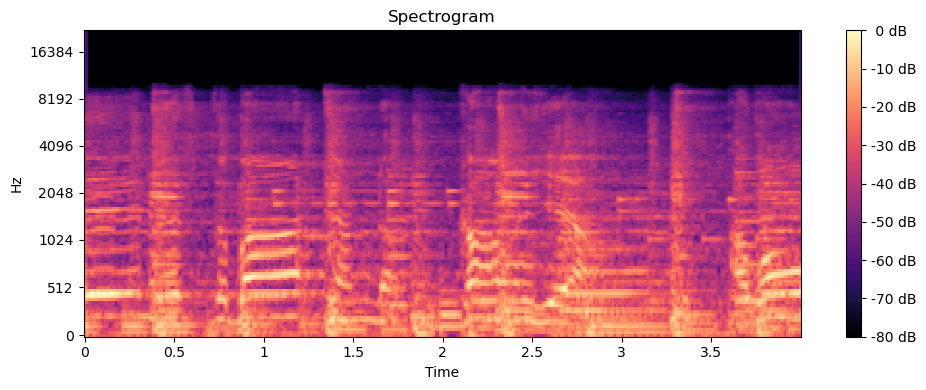

(128, 345)


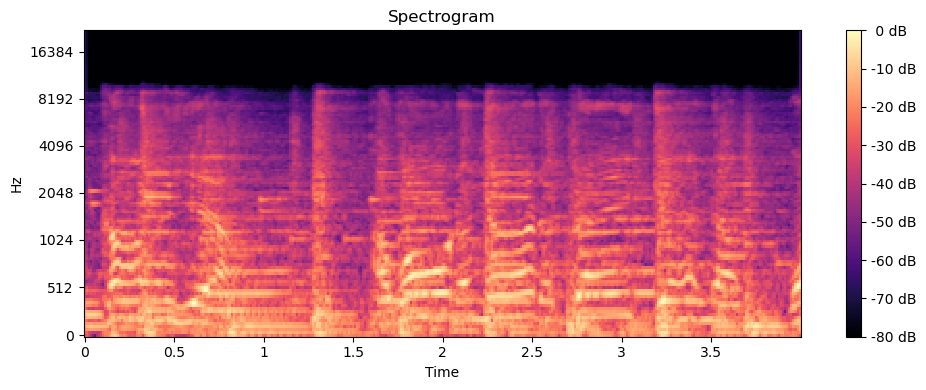

(128, 345)


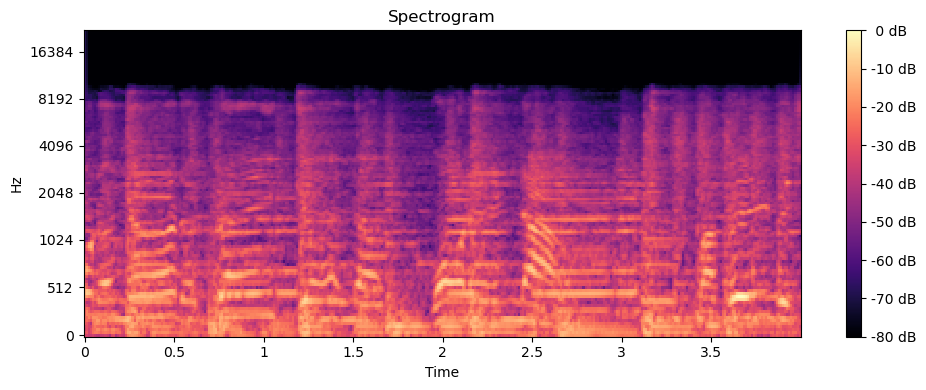

(128, 345)


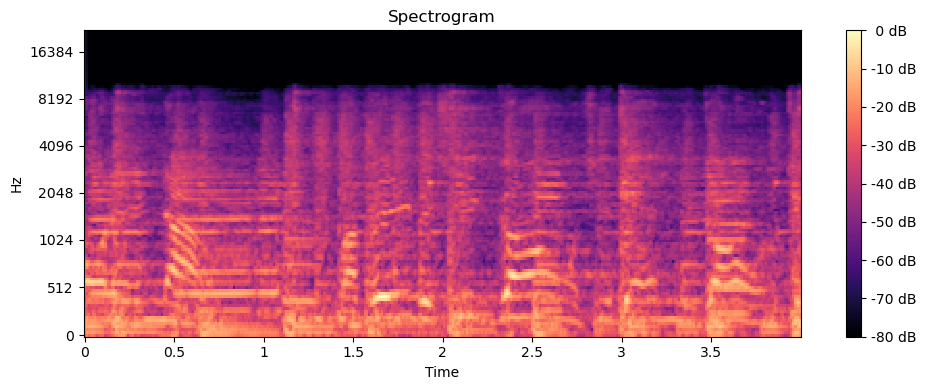

(128, 345)


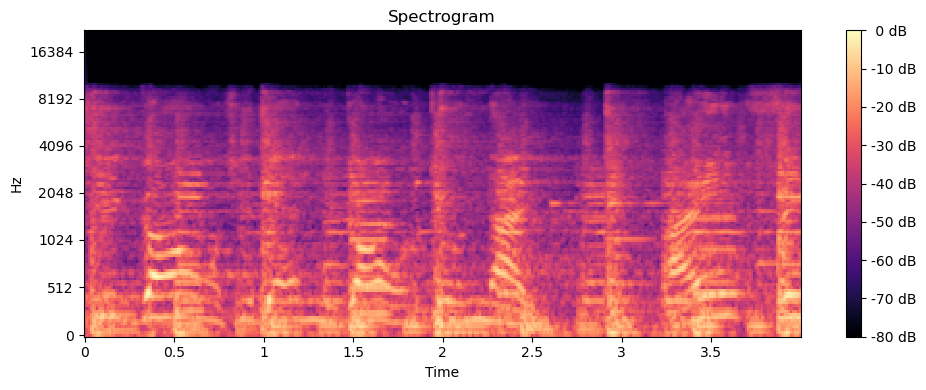

(128, 345)


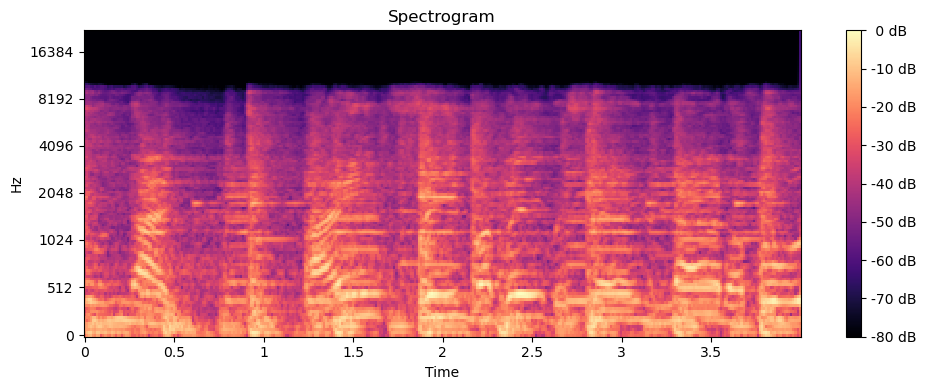

(128, 345)


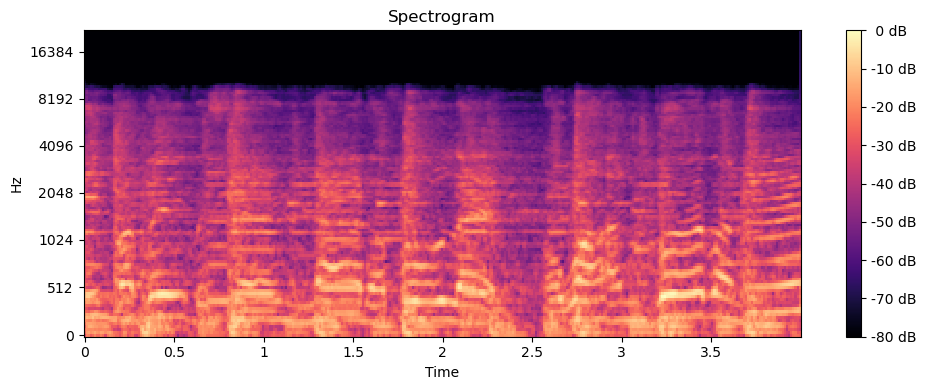

(128, 345)


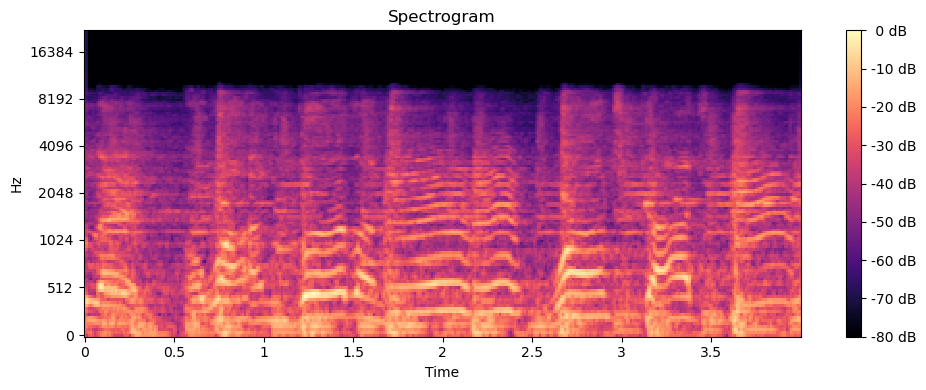

(128, 345)


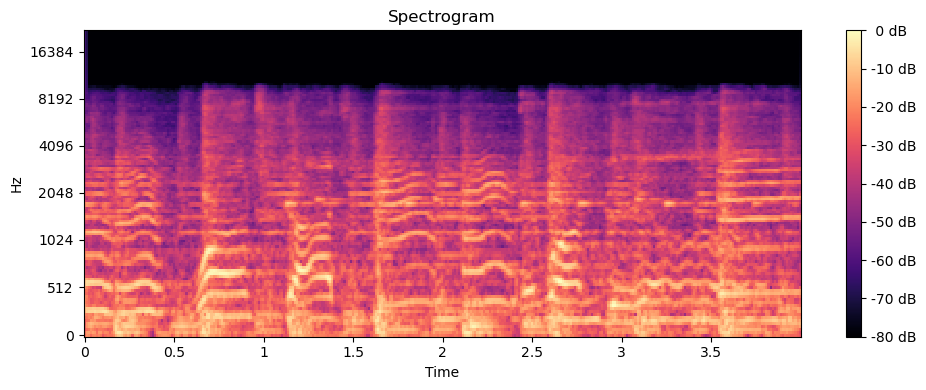

(128, 345)


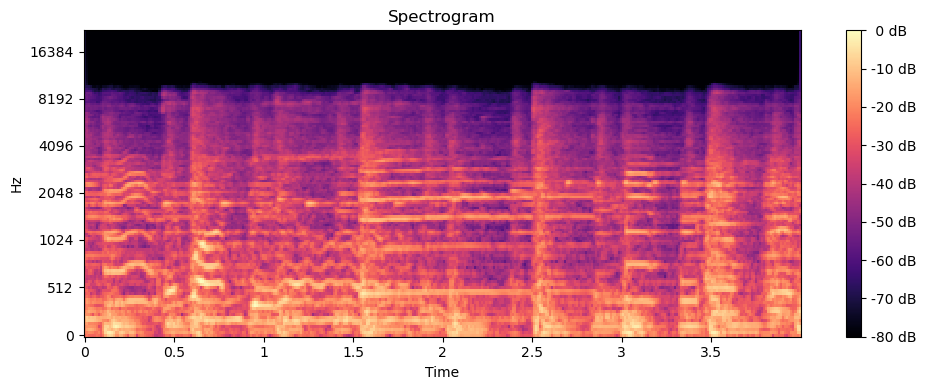

(128, 174)


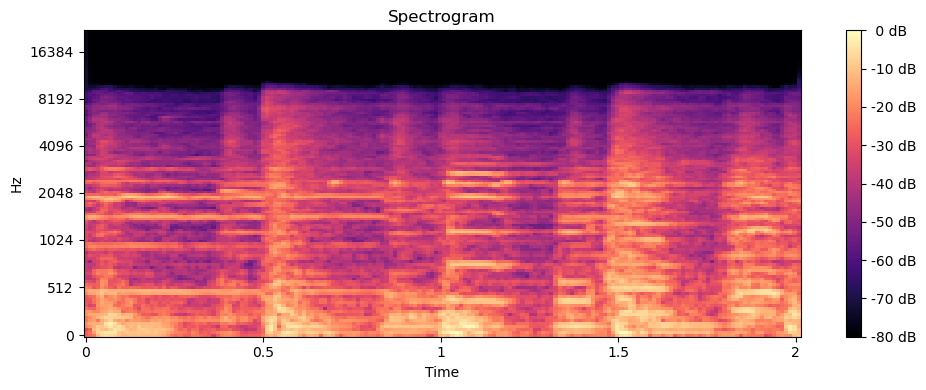

In [ ]:
y, sr = librosa.load(random_file_name, sr = 44100)
plot_melspectrogram_chunks(y, sr)

In [ ]:
128*245

31360

# Data Preprocessing

In [ ]:
## folder structur
data_dir = "./Data/genres_original/"
classes = ['blues', 'classical','country','disco','hiphop','jazz','metal','pop','reggae','rock']


In [ ]:
from tensorflow.image import resize

In [ ]:
def load_and_preprocess_data(data_dir, classes, target_shape=(150,150)):

    # list to store spectrogram data
    data = []

    # list to store labels
    labels = []

    # loop through each genre folder
    for i_class, class_name in enumerate(classes):

        class_dir = os.path.join(data_dir, class_name)
        print("Processing--", class_name)

        # loop through audio files in the folder
        for filename in os.listdir(class_dir):

            if filename.endswith('.wav'):

                file_path = os.path.join(class_dir, filename)

                # try loading the audio file (skip corrupted ones)
                try:
                    audio_data, sample_rate = librosa.load(file_path, sr=None)
                except:
                    print("Skipping corrupted file:", file_path)
                    continue

                # chunk parameters
                chunk_duration = 4      # seconds
                overlap_duration = 2    # seconds

                # convert seconds to samples
                chunk_samples = chunk_duration * sample_rate
                overlap_samples = overlap_duration * sample_rate

                # calculate number of chunks
                num_chunks = int(np.ceil(
                    (len(audio_data) - chunk_samples) /
                    (chunk_samples - overlap_samples)
                )) + 1

                # process each chunk
                for i in range(num_chunks):

                    start = i * (chunk_samples - overlap_samples)
                    end = start + chunk_samples

                    chunk = audio_data[start:end]

                    # create mel spectrogram
                    mel_spectrogram = librosa.feature.melspectrogram(
                        y=chunk, sr=sample_rate
                    )

                    # resize spectrogram for CNN input
                    mel_spectrogram = resize(
                        np.expand_dims(mel_spectrogram, axis=-1),
                        target_shape
                    )

                    # store data and label
                    data.append(mel_spectrogram)
                    labels.append(i_class)

    # convert lists to numpy arrays
    return np.array(data), np.array(labels)


In [ ]:
data, labels = load_and_preprocess_data(data_dir, classes)

Processing-- blues
Processing-- classical
Processing-- country
Processing-- disco
Processing-- hiphop
Processing-- jazz


C:\Users\adars\AppData\Local\Temp\ipykernel_17104\179631780.py:24: UserWarning: PySoundFile failed. Trying audioread instead.
  audio_data, sample_rate = librosa.load(file_path, sr=None)
e:\Softwares\Anaconda\envs\music\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Skipping corrupted file: ./Data/genres_original/jazz\jazz.00054.wav
Processing-- metal
Processing-- pop
Processing-- reggae
Processing-- rock


In [ ]:
data.shape

(14975, 150, 150, 1)

In [ ]:
labels.shape

(14975,)

In [ ]:
## One Hot Encoding

In [ ]:
from tensorflow.keras.utils import to_categorical

In [ ]:
labels = to_categorical( labels, num_classes= len(classes)) # converting label to ohe
labels

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(14975, 10))

In [ ]:
labels.shape

(14975, 10)

In [ ]:
np.save("data.npy", data)
np.save("labels.npy", labels)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data = np.load("/content/drive/MyDrive/Musics/data.npy")
labels = np.load("/content/drive/MyDrive/Musics/labels.npy")

# Splitting of Dataset into Training and Test set

In [6]:
X = data.astype("float32")
y = labels.astype("float32")

In [ ]:
!pip install scikit-learn

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Building Model

## Deep Hybrid CRNN Architecture (Custom CNN + Attention + LSTM)

In [8]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Dense, LSTM, Reshape, Dropout, Input, Conv2D, MaxPool2D,
    BatchNormalization, Activation, Multiply, Bidirectional
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

### Step 1: Feature Extraction (Custom CNN Blocks)
Native audio processing using standard Convolutional layers.

In [9]:
def build_hybrid_crnn(input_shape, num_classes=10):
    print( "Initializing Hybrid CRNN with input shape:",input_shape)

    input_tensor = Input(shape=input_shape, name="spectrogram_input")

    # Block 1
    x = Conv2D(32, kernel_size=3, padding='same', activation='relu', name="conv_b1_1")(input_tensor)
    x = Conv2D(32, kernel_size=3, activation='relu', name="conv_b1_2")(x)
    x = MaxPool2D(pool_size=2, strides=2, name="pool_b1")(x)
    x = BatchNormalization()(x)

    # Block 2
    x = Conv2D(64, kernel_size=3, padding='same', activation='relu', name="conv_b2_1")(x)
    x = Conv2D(64, kernel_size=3, activation='relu', name="conv_b2_2")(x)
    x = MaxPool2D(pool_size=2, strides=2, name="pool_b2")(x)
    x = BatchNormalization()(x)

    # Block 3
    x = Conv2D(128, kernel_size=3, padding='same', activation='relu', name="conv_b3_1")(x)
    x = Conv2D(128, kernel_size=3, activation='relu', name="conv_b3_2")(x)
    x = MaxPool2D(pool_size=2, strides=2, name="pool_b3")(x)
    x = BatchNormalization()(x)

    # Block 4
    x = Conv2D(256, kernel_size=3, padding='same', activation='relu', name="conv_b4_1")(x)
    x = Conv2D(256, kernel_size=3, activation='relu', name="conv_b4_2")(x)
    x = MaxPool2D(pool_size=2, strides=2, name="pool_b4")(x)
    x = BatchNormalization()(x)

    return input_tensor, x

### Step 2: Temporal Bridge & Attention Mechanism
Converting 2D spatial features into a chronological timeline and focusing on dominant musical hits.

In [10]:
def apply_temporal_and_attention(features):
    shape = features.shape
    time_steps = shape[1] * shape[2]
    feature_dims = shape[3]

    # Reshape Spatial to Sequential
    seq_features = Reshape(target_shape=(time_steps, feature_dims), name="temporal_reshape")(features)

    # Custom Temporal Attention
    attention = Dense(feature_dims, activation='softmax', name="attention_weights")(seq_features)
    attention_mul = Multiply(name="attention_multiply")([seq_features, attention])

    return attention_mul

### Step 3: Recurrent Memory (Bi-LSTM) & Classification Head
Processing rhythm and classifying the genre.

In [11]:
def build_classification_head(attention_features, num_classes):
    print("Building Bidirectional LSTM Layers...")
    lstm_out = Bidirectional(
        LSTM(128, return_sequences=True, dropout=0.3),
        name="Bi_LSTM_1"
    )(attention_features)

    lstm_out = Bidirectional(
        LSTM(64, return_sequences=False, dropout=0.3),
        name="Bi_LSTM_2"
    )(lstm_out)

    # Classification Head
    fc = Dense(256, kernel_regularizer=l2(0.001), name="FC_1")(lstm_out)
    fc = BatchNormalization()(fc)
    fc = Activation('relu')(fc)
    fc = Dropout(0.5)(fc)

    predictions = Dense(num_classes, activation='softmax', name="genre_classifier")(fc)
    return predictions

### Assembly & Compilation

In [12]:
# Assembly
input_tensor, cnn_features = build_hybrid_crnn(input_shape=X_train[0].shape)
attended_features = apply_temporal_and_attention(cnn_features)
predictions = build_classification_head(attended_features, num_classes=10)

model = Model(inputs=input_tensor, outputs=predictions, name="Hybrid_Custom_CRNN")

# Compilation
optimizer = Adam(learning_rate=1e-3) # Standard learning rate for custom architecture (1e-3)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Initializing Hybrid CRNN with input shape: (150, 150, 1)
Building Bidirectional LSTM Layers...


Model: "Hybrid_Custom_CRNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ spectrogram_input   │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_b1_1 (Conv2D)  │ (None, 150, 150,  │        320 │ spectrogram_inpu… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_b1_2 (Conv2D)  │ (None, 148, 148,  │      9,248 │ conv_b1_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_b1             │ (None, 74, 74,    │          0 │ conv_b1_2[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 74, 74,    │        128 │ pool_b1[0][0]     │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_b2_1 (Conv2D)  │ (None, 74, 74,    │     18,496 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_b2_2 (Conv2D)  │ (None, 72, 72,    │     36,928 │ conv_b2_1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_b2             │ (None, 36, 36,    │          0 │ conv_b2_2[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 36,    │        256 │ pool_b2[0][0]     │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_b3_1 (Conv2D)  │ (None, 36, 36,    │     73,856 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_b3_2 (Conv2D)  │ (None, 34, 34,    │    147,584 │ conv_b3_1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_b3             │ (None, 17, 17,    │          0 │ conv_b3_2[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 17,    │        512 │ pool_b3[0][0]     │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_b4_1 (Conv2D)  │ (None, 17, 17,    │    295,168 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_b4_2 (Conv2D)  │ (None, 15, 15,    │    590,080 │ conv_b4_1[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_b4             │ (None, 7, 7, 256) │          0 │ conv_b4_2[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 256) │      1,024 │ pool_b4[0][0]   

 Total params: 1,834,602 (7.00 MB)

 Trainable params: 1,833,130 (6.99 MB)

 Non-trainable params: 1,472 (5.75 KB)

### Step 4: Callbacks & Training

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Callbacks ensure the model learns optimally
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

# Ensure new name to NOT overwrite the previous model
checkpoint = ModelCheckpoint("Hybrid_CRNN_Model.keras", monitor='val_accuracy', save_best_only=True, verbose=1)

training_history = model.fit(
    X_train,
    y_train,
    epochs=50, # More epochs to accommodate LSTM learning
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, lr_scheduler, checkpoint]
)


Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.2436 - loss: 2.2174
Epoch 1: val_accuracy improved from None to 0.34157, saving model to Hybrid_CRNN_Model.keras

Epoch 1: finished saving model to Hybrid_CRNN_Model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 51s 98ms/step - accuracy: 0.3457 - loss: 1.9441 - val_accuracy: 0.3416 - val_loss: 2.0434 - learning_rate: 0.0010
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5061 - loss: 1.5113
Epoch 2: val_accuracy improved from 0.34157 to 0.36394, saving model to Hybrid_CRNN_Model.keras

Epoch 2: finished saving model to Hybrid_CRNN_Model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 75s 95ms/step - accuracy: 0.5320 - loss: 1.4425 - val_accuracy: 0.3639 - val_loss: 1.8718 - learning_rate: 0.0010
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.6071 - loss: 1.2547
Epoch 3: val_accuracy did not improve from 0.36394
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 95ms/step - accuracy: 0.6176 - loss: 1.2079 - val_accuracy: 0.

In [ ]:
from tensorflow.keras.models import load_model
model = load_model('Hybrid_CRNN_Model.keras')
print('Best model loaded successfully!')

### Saving New Model History

In [14]:
import json
with open('hybrid_training_hist.json', 'w') as f:
    json.dump(training_history.history, f)
print("Saved hybrid_training_hist.json")

Saved hybrid_training_hist.json


In [19]:
#Reloading Training history
import json
with open("hybrid_training_hist.json",'r') as json_file:
    training_history_data = json.load(json_file)

In [16]:
training_history_data.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])

# Performance Analytics

### 1. Final Model Metrics
Checking accuracy on both training and validation sets.

In [17]:
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("--- Model Metrics ---")
print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Test Accuracy:  {test_acc*100:.2f}%")
print(f"Train Loss: {train_loss:.4f}")
print(f"Test Loss:  {test_loss:.4f}")
print("---------------------")

--- Model Metrics ---
Train Accuracy: 99.84%
Test Accuracy:  94.19%
Train Loss: 0.0138
Test Loss:  0.2417
---------------------


### 2. Learning Curves
Visualizing how the model improved over epochs.

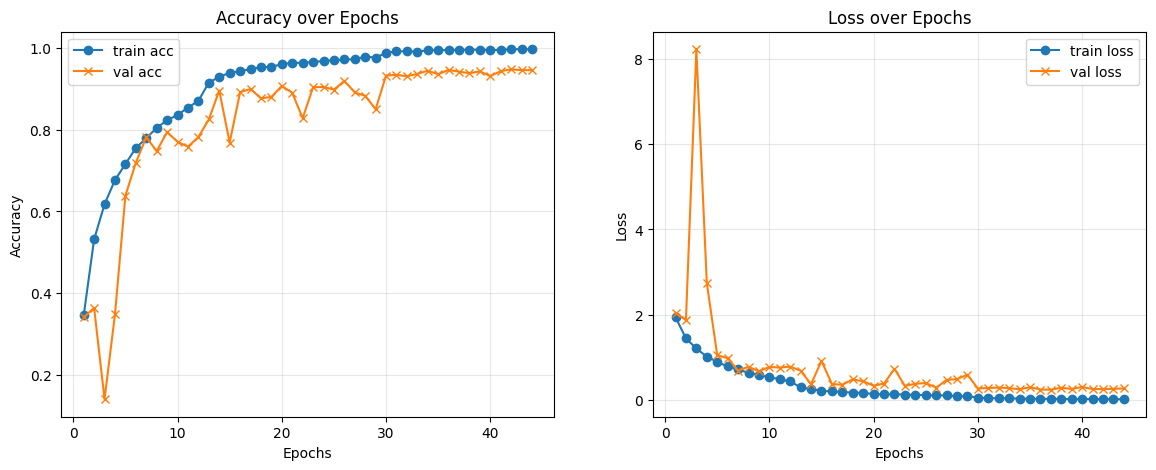

In [18]:
import matplotlib.pyplot as plt

hist = training_history.history
epochs = range(1, len(hist['loss']) + 1)

plt.figure(figsize=(14, 5))

# accuracy graph
plt.subplot(1, 2, 1)
plt.plot(epochs, hist['accuracy'], label='train acc', marker='o')
plt.plot(epochs, hist['val_accuracy'], label='val acc', marker='x')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

# loss graph
plt.subplot(1, 2, 2)
plt.plot(epochs, hist['loss'], label='train loss', marker='o')
plt.plot(epochs, hist['val_loss'], label='val loss', marker='x')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 3. Detailed Classification Report
Precision, Recall, and F1-Score per genre.

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Updated class list
genre_labels = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

# Get predictions
y_pred_probs = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate report
print("\n" + "="*60)
print("              GENRE CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=genre_labels))
print("="*60)

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step

              GENRE CLASSIFICATION REPORT
              precision    recall  f1-score   support

       blues       0.99      0.91      0.95       302
   classical       0.95      0.98      0.97       298
     country       0.92      0.89      0.90       317
       disco       0.96      0.94      0.95       312
      hiphop       0.98      0.95      0.97       277
        jazz       0.94      0.94      0.94       311
       metal       0.97      0.97      0.97       302
         pop       0.90      0.94      0.92       289
      reggae       0.97      0.95      0.96       296
        rock       0.86      0.96      0.90       291

    accuracy                           0.94      2995
   macro avg       0.94      0.94      0.94      2995
weighted avg       0.94      0.94      0.94      2995



### 4. Confusion Matrix Heatmap
Identifying which genres are being confused by the model.

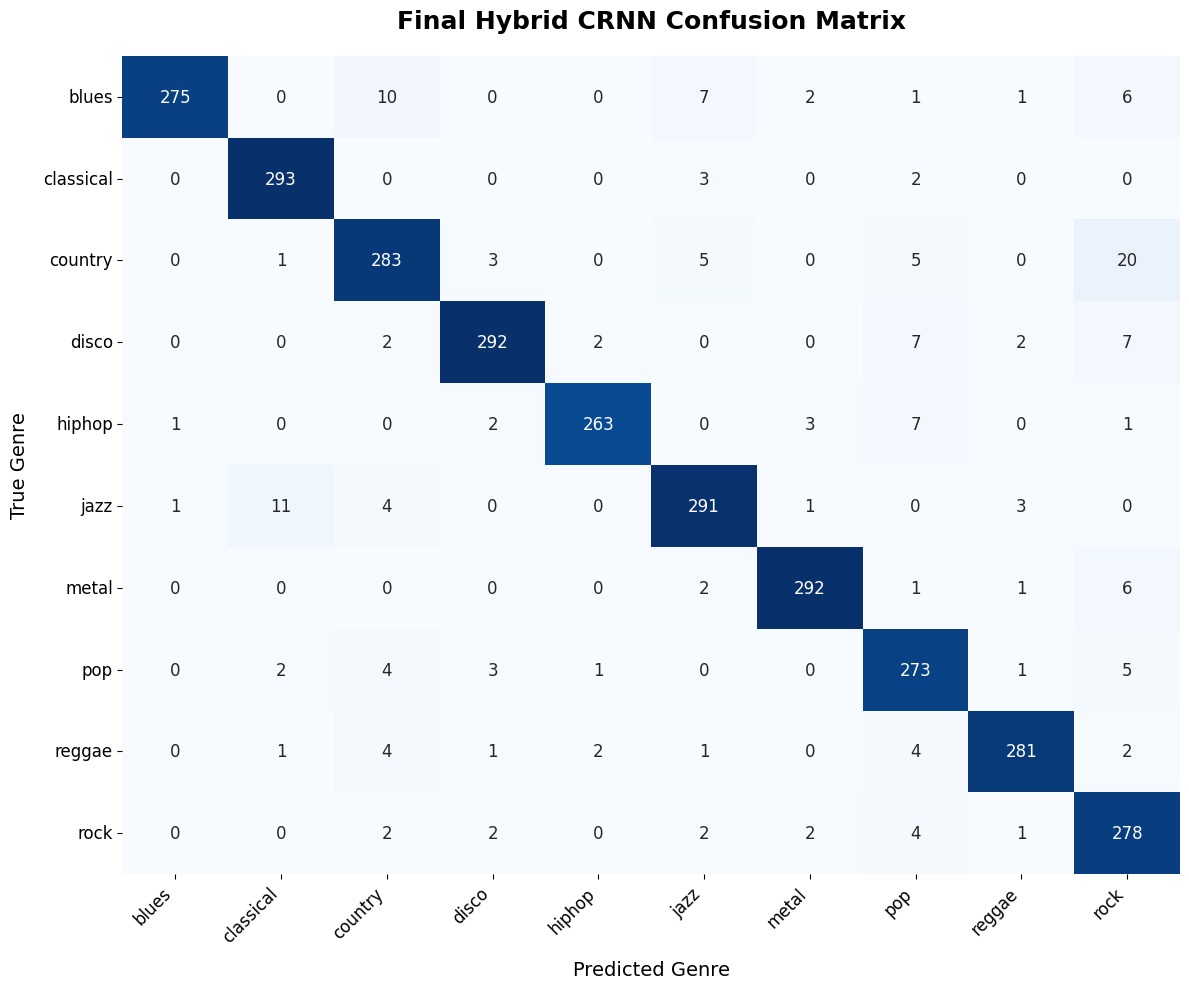

In [22]:
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=genre_labels, yticklabels=genre_labels,
            annot_kws={"size": 12}, cbar=False)

plt.title('Final Hybrid CRNN Confusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Predicted Genre', fontsize=14, labelpad=10)
plt.ylabel('True Genre', fontsize=14, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()

### 5. Final Model Comparison
How the new Hybrid model stacks up against previous benchmarks.

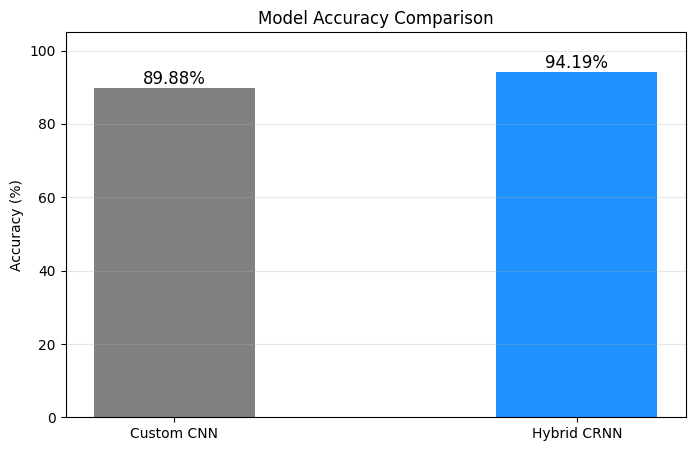

accuracy improved by 4.31%


In [23]:
old_acc = 89.88
new_acc = test_acc * 100

models = ['Custom CNN', 'Hybrid CRNN']
acc_scores = [old_acc, new_acc]

plt.figure(figsize=(8, 5))
b = plt.bar(models, acc_scores, color=['gray', 'dodgerblue'], width=0.4)

# adding the numbers on top
for i in b:
    val = i.get_height()
    plt.text(i.get_x() + i.get_width()/2, val + 1,
             f'{val:.2f}%', ha='center', fontsize=12)

plt.ylim(0, 105)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.grid(axis='y', alpha=0.3)
plt.show()

diff = new_acc - old_acc
if diff > 0:
    print(f"accuracy improved by {diff:.2f}%")
else:
    print(f"diff: {diff:.2f}%")